In [16]:
%load_ext autoreload
%autoreload 2
from utils import *
from jax.example_libraries import stax
from numpyro import optim
from CustomModules.architectures import *
from CustomModules.normalizing_flow import normalizing_flow
from sklearn.datasets import fetch_openml
import sklearn
from sklearn.metrics import mean_squared_error
import pandas as pd

import pickle
import os

import jax
import jax.numpy as jnp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Jax psuedo random keys


In [17]:

# For reproducibility, we define a deterministic hashing function for our random keys
# Each unique string will correspond to a unique random independent key, but the same string will always yield the same key.
# Here I make sure to start at a different key from Toy Data experiments
key_for = make_key_for(jax.random.key(1))

# Data

In [18]:

mnist = fetch_openml("mnist_784")
mnist_data = np.array(mnist.data) / 255.0
mnist_targets = np.array(mnist.target).astype(int)

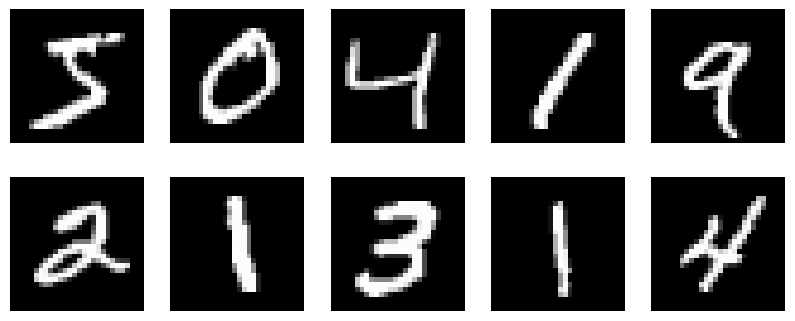

In [19]:
plot_images(mnist_data[:10], shape=(28, 28))

In [20]:
diff = mnist_data.max() - mnist_data.min()

# squish the data to be between 0 and 1
mnist_data = (mnist_data - mnist_data.min()) / diff if mnist_data.max() != mnist_data.min() else mnist_data

X_train_p, X_test_p, y_train, y_test = sklearn.model_selection.train_test_split(mnist_data, mnist_targets, test_size=0.2, random_state=42)



# Binarize by sampling from it as a distrubution

X_train = np.random.binomial(1, X_train_p)
X_test = np.random.binomial(1, X_test_p)


batch_size = 128

train_loader = [X_train[i:i+batch_size] for i in range(0, len(X_train), batch_size)]
test_loader = [X_test[i:i+batch_size] for i in range(0, len(X_test), batch_size)]

train_size = len(X_train)
test_size = len(X_test)

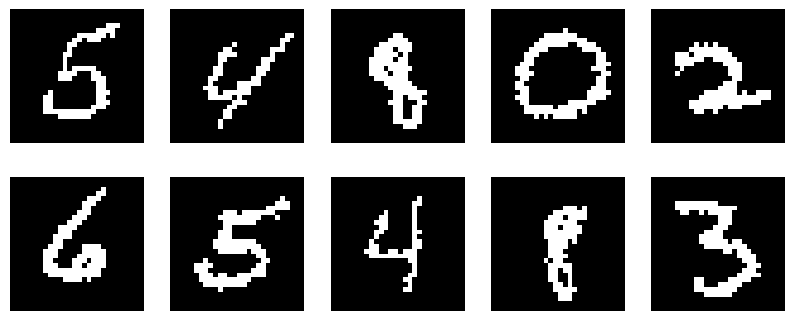

In [21]:
plot_images(X_train[:10], shape=(28, 28))

# Define Model Architectures


## Networks


Here i define the networks. Some stabilizing has been added like clipping, variance floors and predetermined start-variances by shift x

In [22]:
def encoder(hidden_dim, z_dim, variance_floor=0.1):
    SafeSoftplus = stax.elementwise(lambda x: jnp.clip(stax.softplus(x-3.0), min=0.0, max=20.0) + variance_floor)
    return stax.serial(
        stax.Dense(hidden_dim),
        stax.LeakyRelu,
        stax.FanOut(2),
        stax.parallel(
            stax.Dense(z_dim),
            stax.serial(stax.Dense(z_dim), SafeSoftplus),
        ),
    )


def decoder(hidden_dim, out_dim):
    return stax.serial(
        stax.Dense(hidden_dim),
        stax.LeakyRelu,
        stax.Dense(out_dim),
    )

def f_shared(hidden_dim, f_dim):
    return stax.serial(
        stax.Dense(hidden_dim),
        stax.LeakyRelu,
        stax.Dense(hidden_dim),
        stax.LeakyRelu,
        stax.Dense(f_dim),
        stax.elementwise(lambda x: jnp.clip(x, -10.0, 10.0))
    )

def g(z_dim, variance_floor=0.1):
    SafeSoftplus = stax.elementwise(lambda x: jnp.clip(stax.softplus(x-3.0), min=0.0, max=20.0) + variance_floor)
    return stax.serial(
        stax.FanOut(2),
        stax.parallel(
            stax.serial(stax.Dense(z_dim), stax.elementwise(lambda x: jnp.clip(x, -10.0, 10.0))),
            stax.serial(stax.Dense(z_dim), SafeSoftplus),
        )
    )

def h(hidden_dim, h_dim):
    return stax.serial(
        stax.Dense(hidden_dim),
        stax.LeakyRelu,
        stax.Dense(h_dim),
    )

## Hyperparameters


In [23]:

out_dim = X_train.shape[1]
hidden_dim =128
z_dim = 50
m_dim = 5
h_dim = 20


lr=5e-3

def lr_scheduler(lr_start=5e-3, decay_rate=0.9, decay_steps=300, floor=1e-5):
    def schedule(step):
        return lr_start * (decay_rate ** (step // decay_steps)) + floor
    return schedule

encoder_args = {"hidden_dim": hidden_dim, "z_dim": z_dim}
decoder_args = {"hidden_dim": hidden_dim, "out_dim": out_dim}
f_args = {"hidden_dim": z_dim, "f_dim": z_dim}
g_args = {"z_dim": z_dim, "variance_floor": 0.05}
h_args = {"hidden_dim": h_dim, "h_dim": z_dim}
flow_args = {"input_dim": m_dim, "hidden_dims": [m_dim], "steps": 0, "inv": True} # steps: 0 means flow is deactivated
hierarchical_layers = 2 # for the hierarchical model
num_stein_particles = 5
num_elbo_particles = 10
bandwidth_scaler=0.03


num_epochs = 60
annealing_epochs = 15

steps = len(X_train)/batch_size * num_epochs
lr_scheduler_fn = lr_scheduler(lr, decay_rate=0.9, decay_steps=steps/30, floor=1e-5)
adam = optim.ClippedAdam(lr_scheduler_fn, clip_norm=10) # clipping for stability

Show lr_schedule

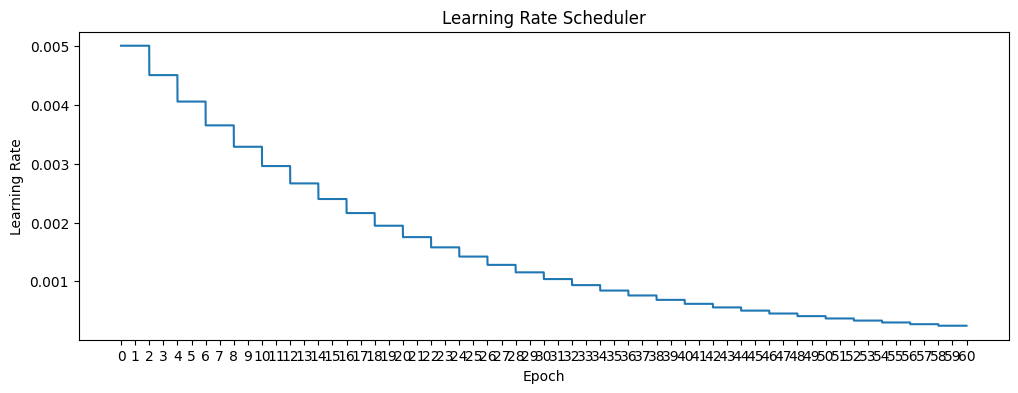

In [24]:
lrs = [lr_scheduler_fn(step) for step in range(int(steps))]
plt.figure(figsize=(12, 4))
plt.plot(lrs)

plt.title("Learning Rate Scheduler")

plt.xticks(np.linspace(0, steps, num_epochs+1), [f"{i}" for i in range(num_epochs+1)])
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.show()


## Define models

In [25]:

ordinary_vae = BaseVAE(encoder, encoder_args, decoder, decoder_args, z_dim, model_mode="b")
stein_global_vae = SteinGlobalVAE(encoder, encoder_args, decoder, decoder_args, z_dim, model_mode="b")
stein_hierarchical_vae = SteinHierarchicalVAE(decoder, decoder_args, f_shared, f_args, h, h_args, g, g_args, g, g_args, hierarchical_layers, z_dim, m_dim, normalizing_flow, flow_args, model_mode="b")

# Training

In [26]:
# Checkpoint names:
checkpoints_dir = "checkpoints_mnist"
if not os.path.exists(checkpoints_dir):
    os.makedirs(checkpoints_dir)
checkpoint_ordinary = f"{checkpoints_dir}/mnist_ordinary_vae_epochs={num_epochs}.pkl"
checkpoint_stein_global = f"{checkpoints_dir}/mnist_stein_global_vae_epochs={num_epochs}_stein_particles={num_stein_particles}.pkl"
checkpoint_stein_hierarchical = f"{checkpoints_dir}/mnist_stein_hierarchical_vae_epochs={num_epochs}_stein_particles={num_stein_particles}.pkl"



If checkpoint already exists, then just load it, otherwise train. This ensures no wasted time

In [27]:
if os.path.exists(checkpoint_ordinary):
    with open(checkpoint_ordinary, "rb") as f:
        ordinary_vae = pickle.load(f)
    print("Loaded Ordinary VAE from checkpoint.")
else:
    ordinary_vae.train(train_loader, train_size, adam, num_epochs,  key_for("ordinary_vae_training"), annealing_epochs=annealing_epochs)
    with open(checkpoint_ordinary, "wb") as f:
        pickle.dump(ordinary_vae, f)
    print("Trained and saved Ordinary VAE.")

Loaded Ordinary VAE from checkpoint.


In [28]:
if os.path.exists(checkpoint_stein_global):
    with open(checkpoint_stein_global, "rb") as f:
        stein_global_vae, stein_global_vae_norms = pickle.load(f)
    print("Loaded Stein Global VAE from checkpoint.")
else:
    stein_global_vae_norms = stein_global_vae.train(train_loader, train_size, adam, num_epochs, key_for("stein_global_vae_training3"), num_stein_particles, 
                                                    annealing_epochs=annealing_epochs, num_elbo_particles=num_elbo_particles, bandwidth_scaler = bandwidth_scaler)
    with open(checkpoint_stein_global, "wb") as f:
        pickle.dump((stein_global_vae, stein_global_vae_norms), f)
    print("Trained and saved Stein Global VAE.")

Loaded Stein Global VAE from checkpoint.


In [29]:
if os.path.exists(checkpoint_stein_hierarchical):
    with open(checkpoint_stein_hierarchical, "rb") as f:
        stein_hierarchical_vae, stein_hierarchical_vae_norms = pickle.load(f)
    print("Loaded Stein Hierarchical VAE from checkpoint.")
else:
    stein_hierarchical_vae_norms = stein_hierarchical_vae.train(train_loader, train_size, adam, num_epochs, key_for("stein_hierarchical_vae_training"), 
                                                                num_stein_particles, num_elbo_particles=num_elbo_particles,
                                                                annealing_epochs=annealing_epochs, 
                                                                annealed_sites=[f"z{i}" for i in range(hierarchical_layers)],
                                                                bandwidth_scaler = bandwidth_scaler)
    with open(checkpoint_stein_hierarchical, "wb") as f:
        pickle.dump((stein_hierarchical_vae, stein_hierarchical_vae_norms), f)
    print("Trained and saved Stein Hierarchical VAE.")


Loaded Stein Hierarchical VAE from checkpoint.


# Results

In [30]:
# reconstruction for baseVAE:
encoded_ordinary = ordinary_vae.encode_batch(X_test, key_for("ordinary_vae_encoding"))
reconstructed_ordinary = np.array(jax.nn.sigmoid(ordinary_vae.decode_latent(encoded_ordinary, key_for("ordinary_vae_decoding"))["x"]))

# reconstruction for global:
encoded_stein_global = stein_global_vae.encode_batch(X_test, key_for("stein_global_vae_encoding"))
reconstructed_stein_global = np.array(jax.nn.sigmoid(stein_global_vae.decode_latent(encoded_stein_global, key_for("stein_global_vae_decoding"))["x"]))

# reconstruction for hierarchical:
encoded_stein_hierarchical = stein_hierarchical_vae.encode_batch(X_test, key_for("stein_hierarchical_vae_encoding"))
reconstructed_stein_hierarchical = np.array(jax.nn.sigmoid(stein_hierarchical_vae.decode_latent(encoded_stein_hierarchical, key_for("stein_hierarchical_vae_decoding"), size_site="z0")["x"]))

In [31]:
samples_ordinary_all =ordinary_vae.sample(key_for("qual_ordinary_vae_sampling"), 10000) 
samples_stein_global_all = stein_global_vae.sample(key_for("qual_stein_global_vae_sampling"), 10000)
samples_stein_hierarchical_all = stein_hierarchical_vae.sample(key_for("qual_stein_hierarchical_vae_sampling"), 10000)


samples_ordinary = np.array(jax.nn.sigmoid(samples_ordinary_all["x"]))
samples_stein_global = np.array(jax.nn.sigmoid(samples_stein_global_all["x"]))
samples_stein_hierarchical = np.array(jax.nn.sigmoid(samples_stein_hierarchical_all["x"]))


## Qualitative Results

### Reconstructions

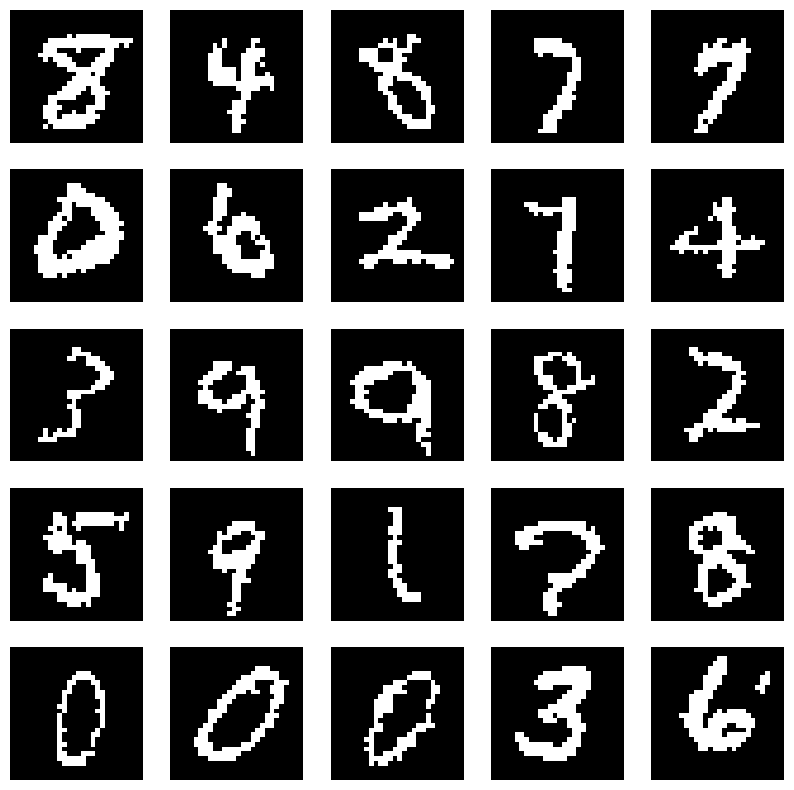

In [32]:
plot_images(X_test[:25], shape=(28, 28))

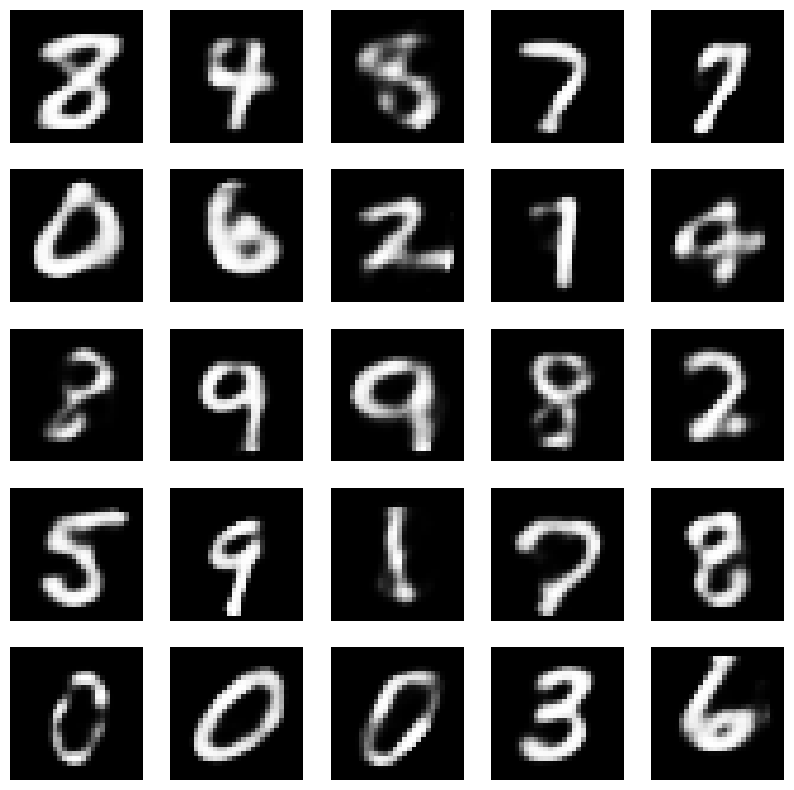

In [33]:
plot_images(reconstructed_ordinary[:25], shape=(28, 28))

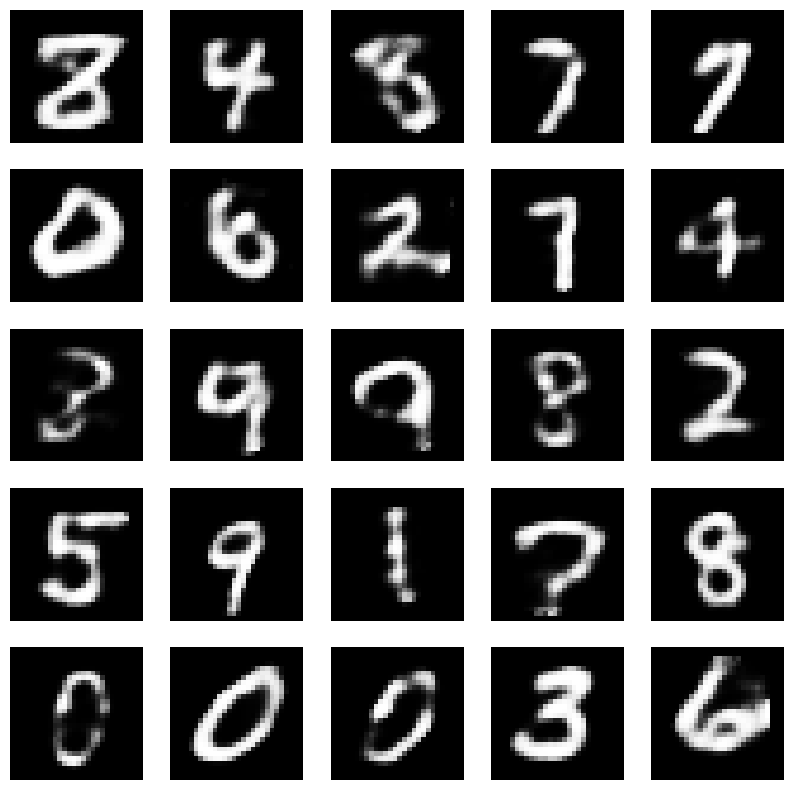

In [34]:

plot_images(reconstructed_stein_global[:25], shape=(28, 28))

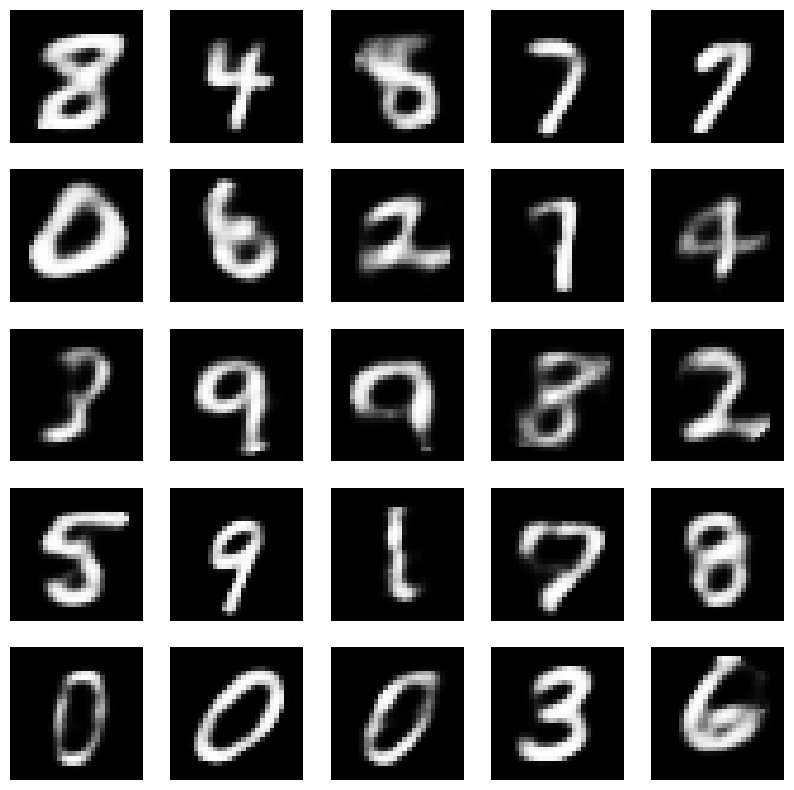

In [35]:
# Hierarchical model
plot_images(reconstructed_stein_hierarchical[:25], shape=(28, 28))

### Samples

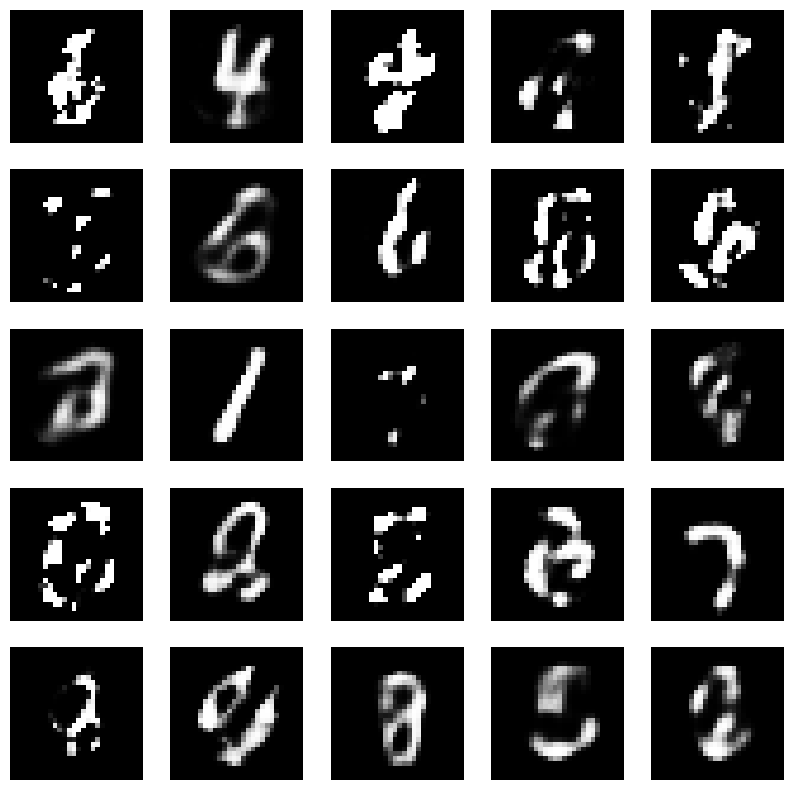

In [36]:
# samples from ordinary:
plot_images(samples_ordinary[0:25], shape=(28, 28))    

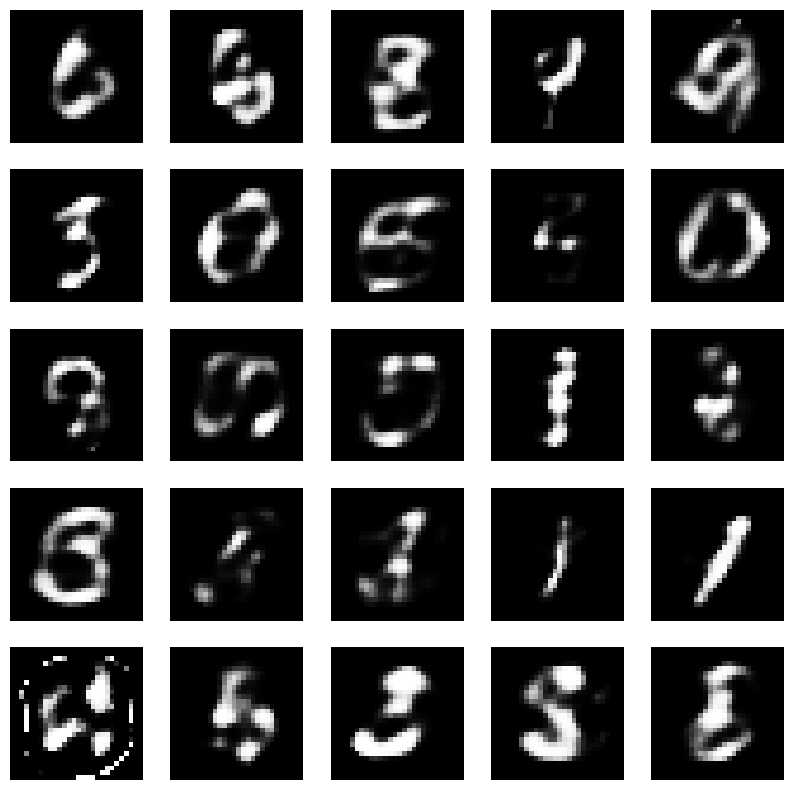

In [37]:
# samples from global:
plot_images(samples_stein_global[0:25], shape=(28, 28))

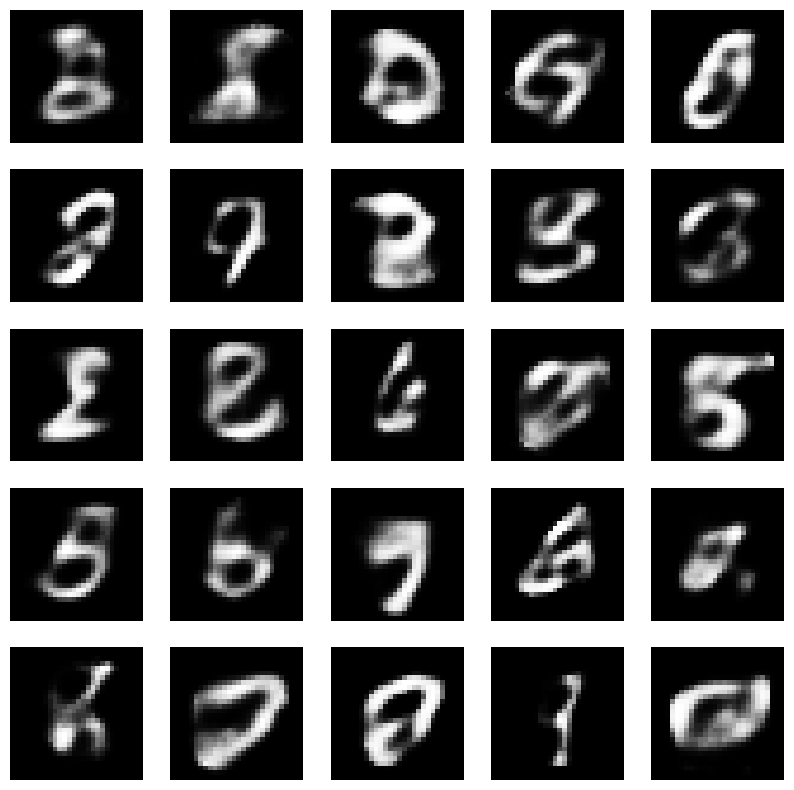

In [38]:
# samples from hierarchical:
plot_images(samples_stein_hierarchical[0:25], shape=(28, 28))

## Quantitative Results

### Reconstructions (MSE)

In [39]:
mse_ordinary = mean_squared_error(X_test, reconstructed_ordinary)
mse_stein_global = mean_squared_error(X_test, reconstructed_stein_global)
mse_stein_hierarchical = mean_squared_error(X_test, reconstructed_stein_hierarchical)

stats = pd.DataFrame({
    "Model": ["Ordinary VAE", "Stein Global VAE", "Stein Hierarchical VAE"],
    "MSE": [mse_ordinary, mse_stein_global, mse_stein_hierarchical]
})



### Samples (FID and LL)

#### LL
We use the RenyiELBO with alpha = 0. This corresponds to the IWAE objective which is an estimate of the true Log prob of the sample densities.

In [40]:
# ordinary VAE iwae evaluation:
iwae_ordinary = ordinary_vae.evaluate_iwae(
    dataloader=test_loader,
    size=test_size,
    rng_key=key_for("ordinary_vae_evaluation"),
    num_particles=5000,
)["avg_iwae"]

#global Stein VAE iwae evaluation:
iwae_stein_global = stein_global_vae.evaluate_iwae(
    dataloader=test_loader,
    size=test_size,
    rng_key=key_for("stein_global_vae_evaluation"),
    num_particles=5000,
)["avg_iwae"]

iwae_stein_hierarchical = stein_hierarchical_vae.evaluate_iwae(
    dataloader=test_loader,
    size=test_size,
    rng_key=key_for("stein_hierarchical_vae_evaluation"),
    num_particles=5000,
)["avg_iwae"]

# add to stats
stats["IWAE"] = [iwae_ordinary, iwae_stein_global, iwae_stein_hierarchical]


In [ ]:
stats

,Model,MSE,IWAE
0,Ordinary VAE,0.033604,-107.47052
1,Stein Global VAE,0.030560,-101.60066
2,Stein Hierarchical VAE,0.035806,-106.47022


#### FID

In [ ]:

fid_calc = FIDCalculator()
fid_ordinary = fid_calc.calculate_fid(torch.tensor(X_test_p), torch.tensor(samples_ordinary))
fid_stein_global = fid_calc.calculate_fid(torch.tensor(X_test_p), torch.tensor(samples_stein_global))
fid_stein_hierarchical = fid_calc.calculate_fid(torch.tensor(X_test_p), torch.tensor(samples_stein_hierarchical))

In [ ]:
# add to stats
stats["FID"] = [fid_ordinary, fid_stein_global, fid_stein_hierarchical]


In [ ]:
stats

,Model,MSE,IWAE,FID
0,Ordinary VAE,0.033604,-107.47052,0.073842
1,Stein Global VAE,0.030560,-101.60066,0.075702
2,Stein Hierarchical VAE,0.035806,-106.47022,0.106500


## Visualizations of Latent Spaces

### Visualization of m global

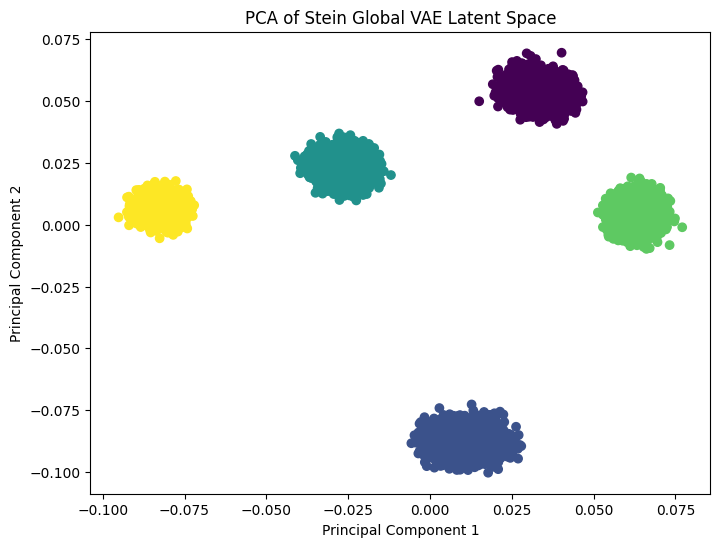

In [45]:
plot_m_colored_pca(encoded_stein_global, title="PCA of Stein Global VAE Latent Space")

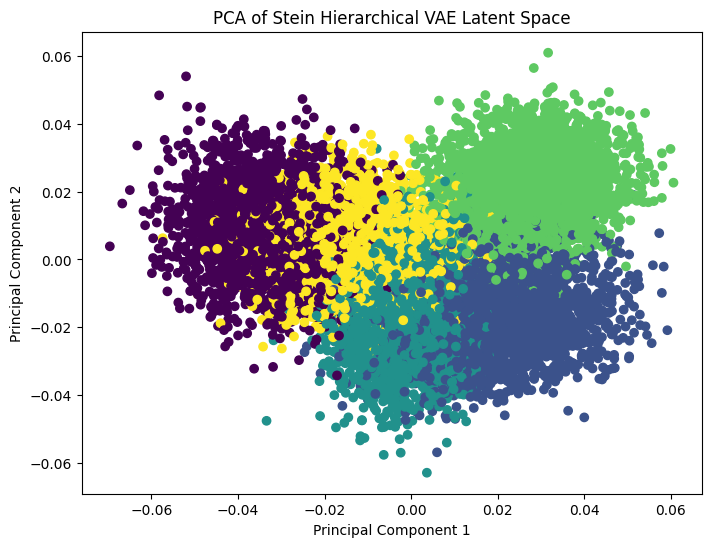

In [ ]:
plot_m_colored_pca(encoded_stein_hierarchical, title="PCA of Stein Hierarchical VAE Latent Space")

### Visualization of z (z or z0)
Here we need to first get a 2d representation for the points, then apply kernel density estimation to get more insight into the densities

#### PCA


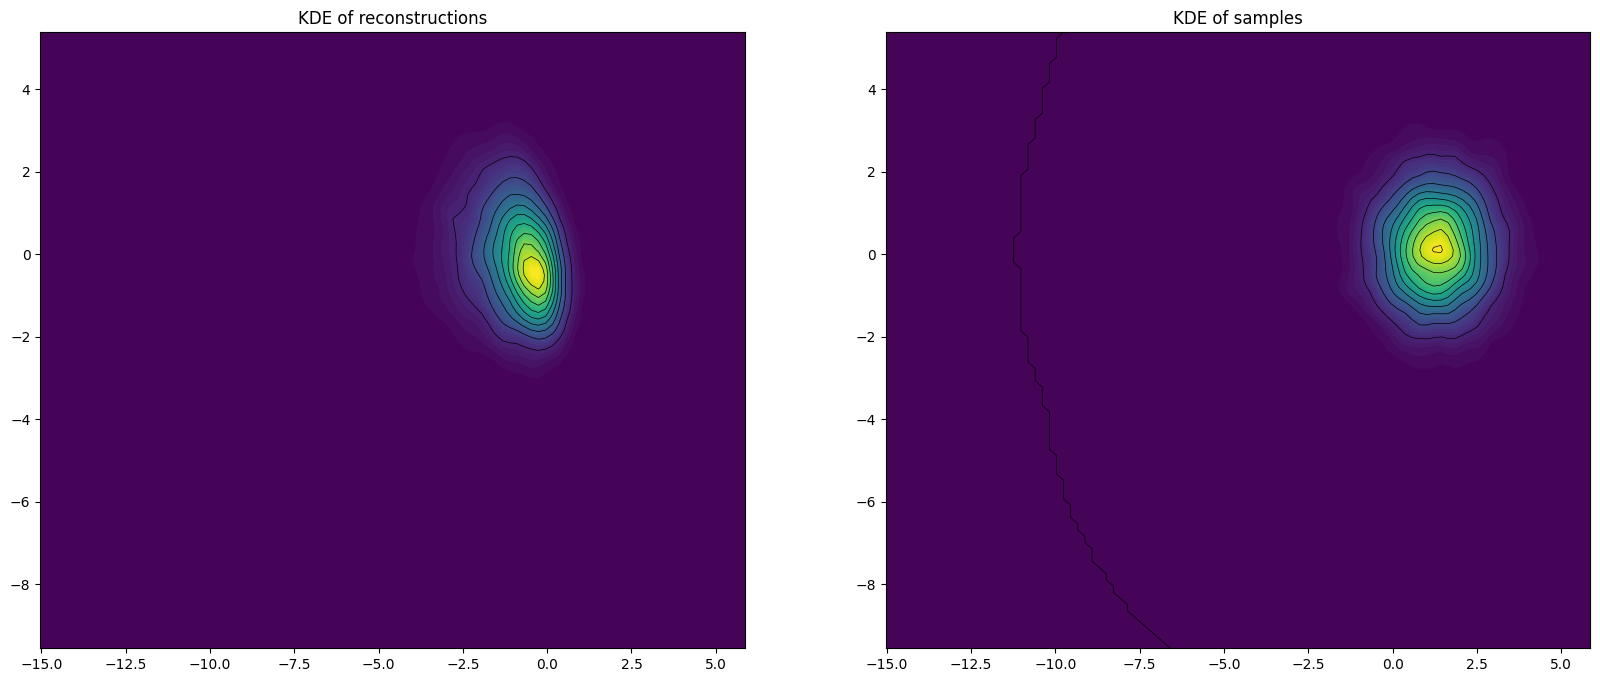

In [ ]:
plot_compare_pca_kde(encoded_ordinary["z"], samples_ordinary_all["z"], title="PCA + KDE of Ordinary VAE Latent Space vs Samples")

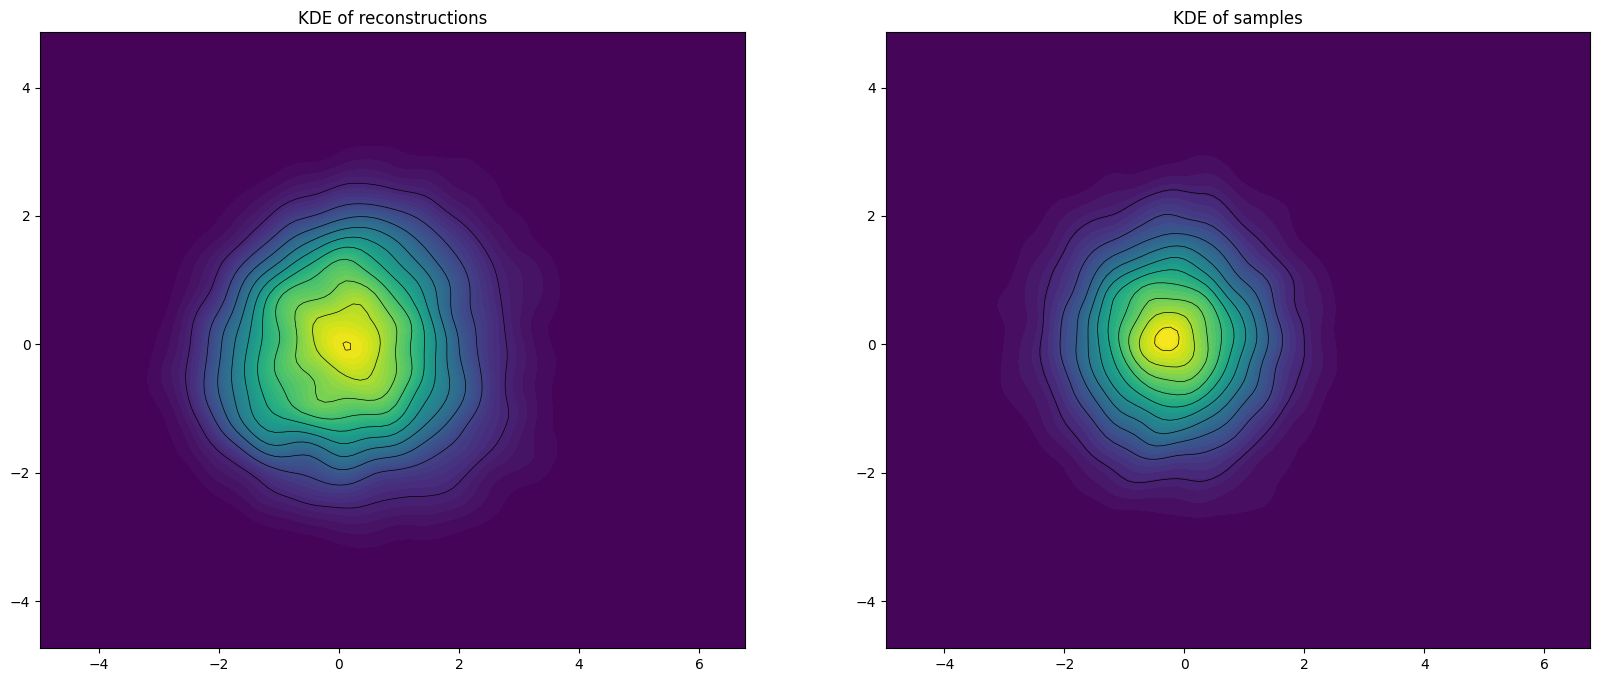

In [ ]:
# for stein global
plot_compare_pca_kde(encoded_stein_global["z"], samples_stein_global_all["z"], title="PCA + KDE of Stein Global VAE Latent Space vs Samples")

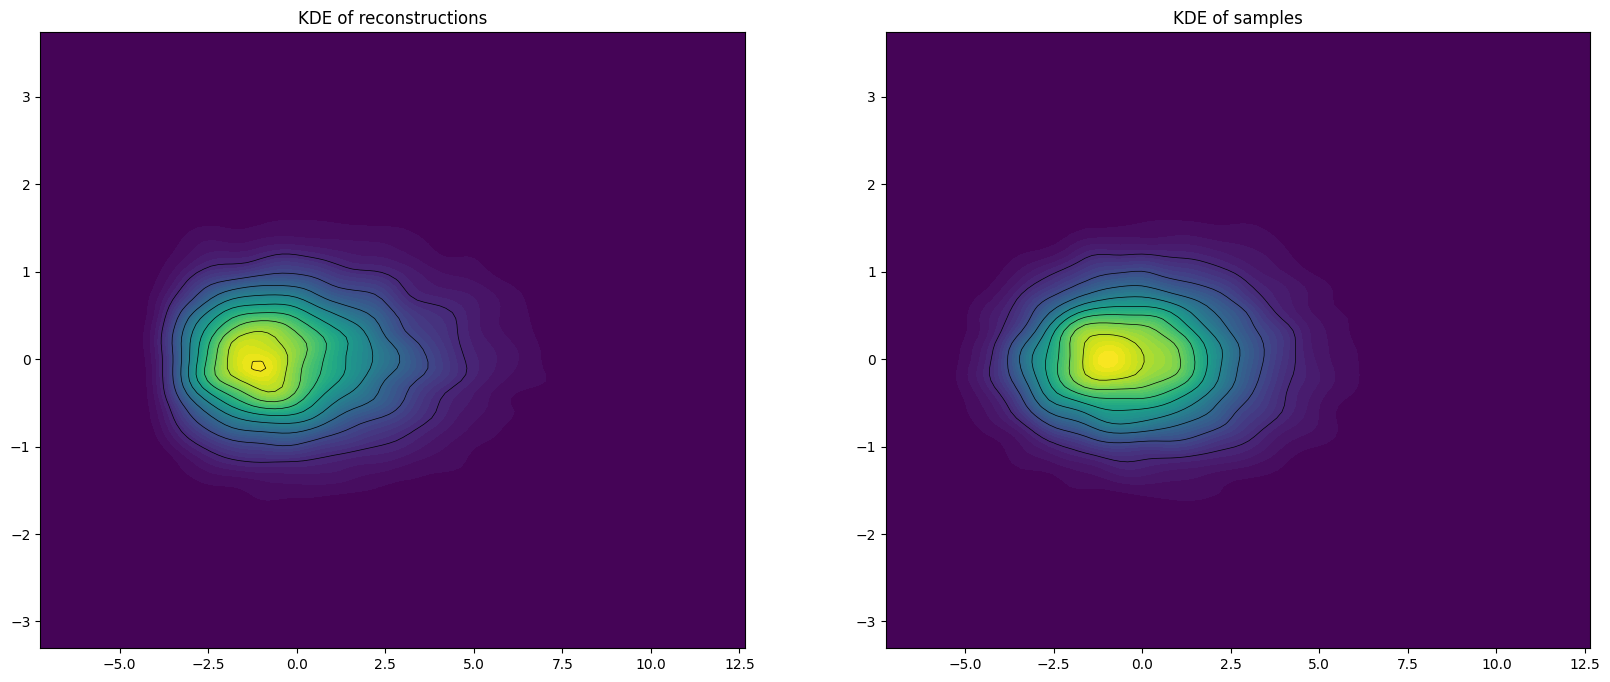

In [ ]:
# for stein hierarchical
plot_compare_pca_kde(encoded_stein_hierarchical["z0"], samples_stein_hierarchical_all["z0"], title="PCA + KDE of Stein Hierarchical VAE Latent Space vs Samples")

#### UMAP

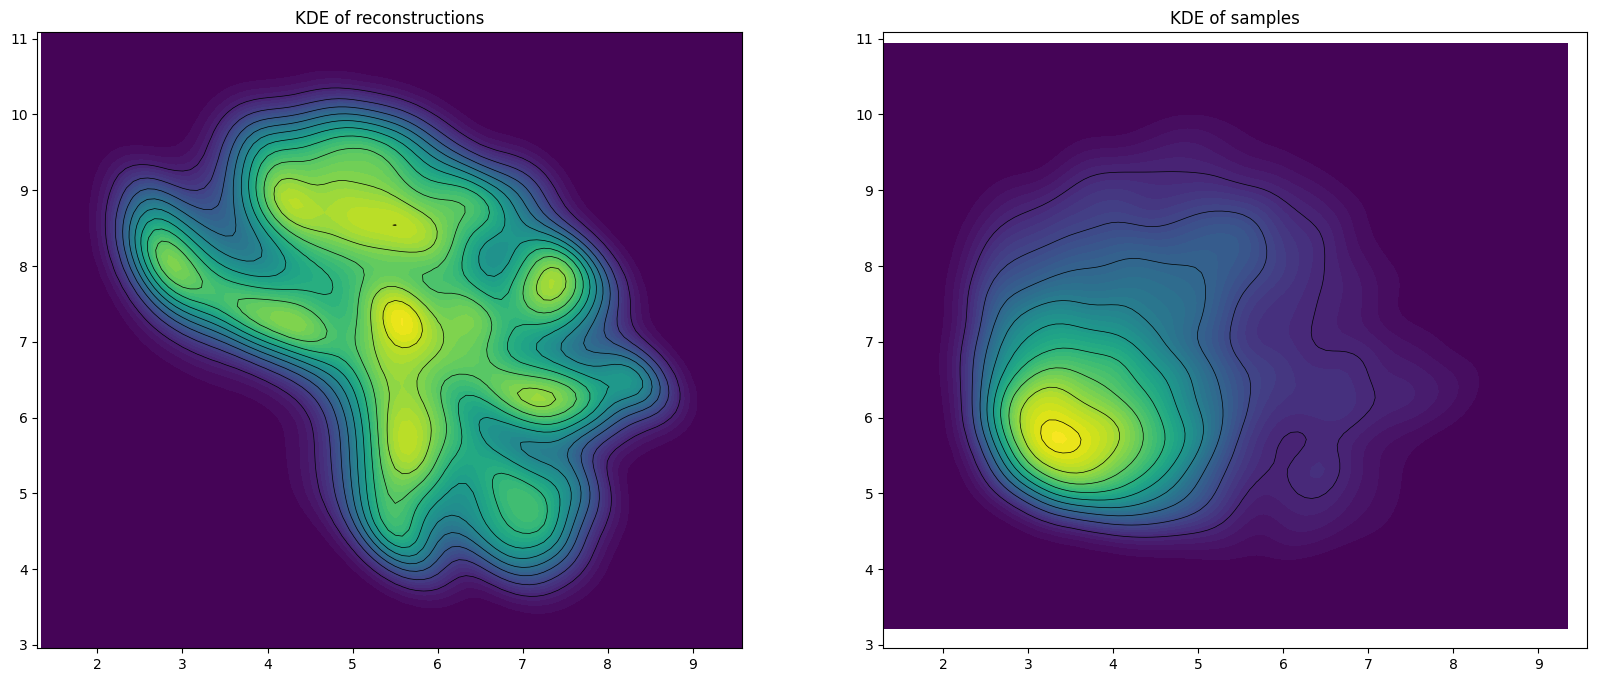

In [ ]:
plot_compare_umap_kde(encoded_ordinary["z"], samples_ordinary_all["z"], title="UMAP + KDE of Ordinary VAE Latent Space vs Samples")

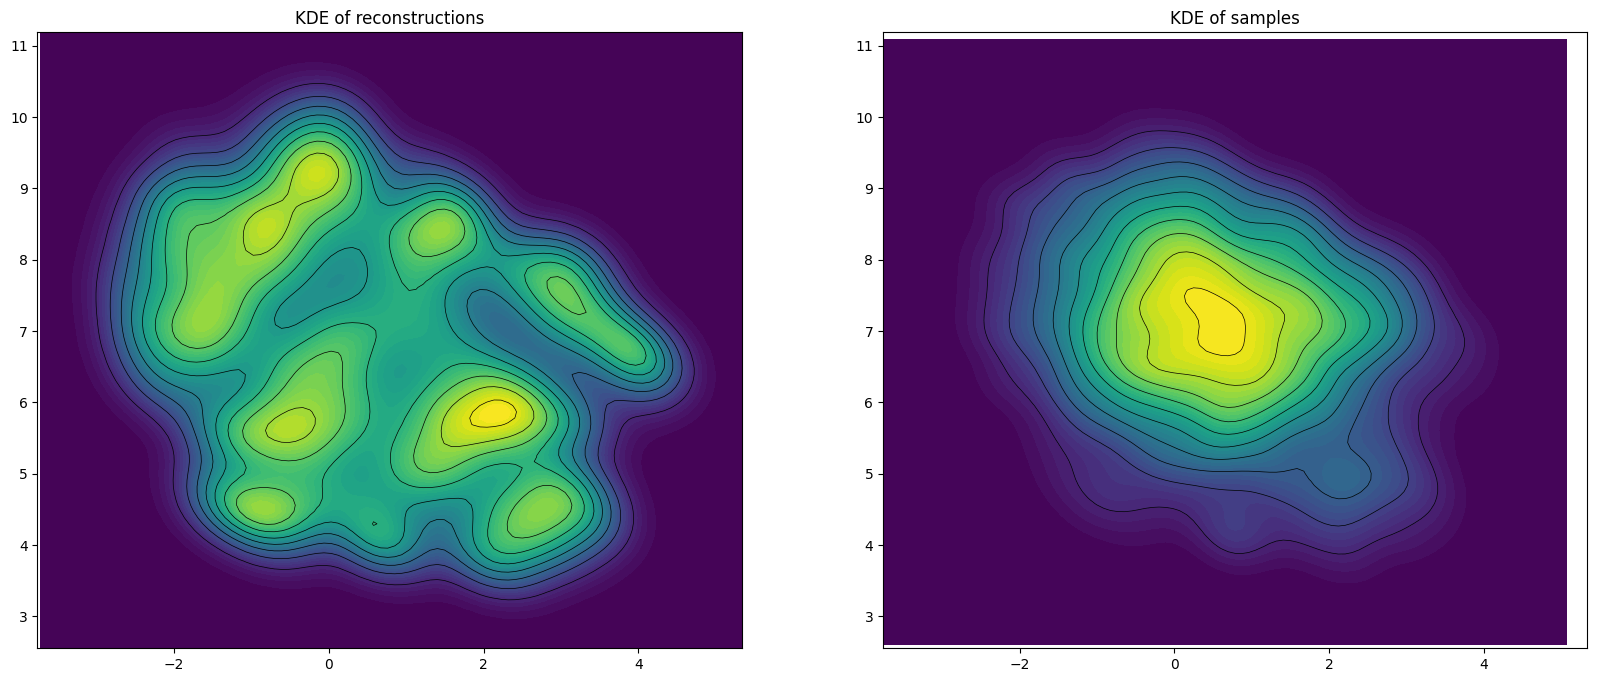

In [ ]:
# for stein global
plot_compare_umap_kde(encoded_stein_global["z"], samples_stein_global_all["z"], title="UMAP + KDE of Stein Global VAE Latent Space vs Samples")

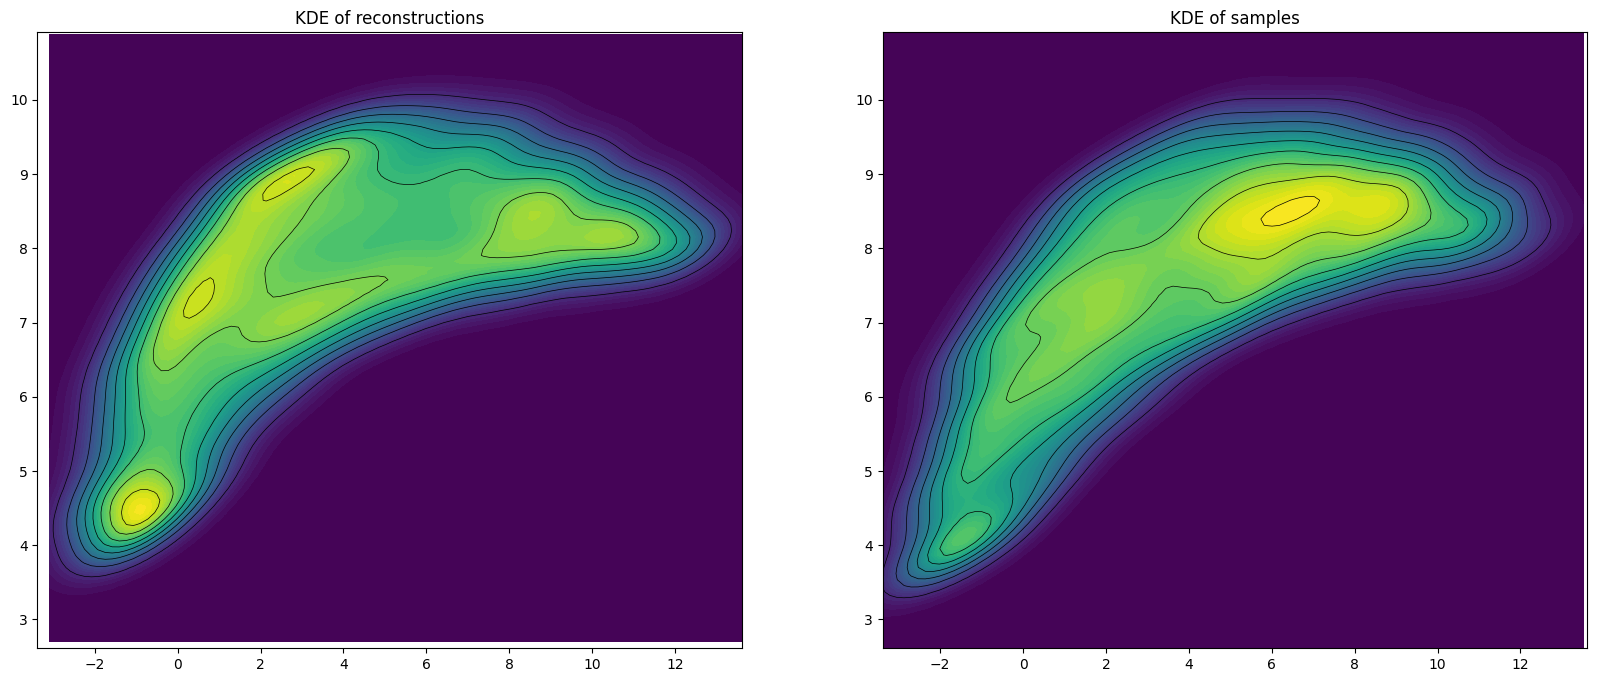

In [ ]:
# for stein hierarchical
plot_compare_umap_kde(encoded_stein_hierarchical["z0"], samples_stein_hierarchical_all["z0"], title="UMAP + KDE of Stein Hierarchical VAE Latent Space vs Samples")

### Linear interpolation

In [ ]:
def plot_linear_interpolation_hierarchical(img1, img2):
    fig, axs = plt.subplots(3, 10, figsize=(15, 6))

    fig.text(0.5, 0.95, "Ordinary VAE Interpolation", ha='center', fontsize=12)
    plot_linear_interpolation(ordinary_vae, key_for("interp_ord"), img1, img2, num_steps=10, ax_list=axs[0])

    fig.text(0.5, 0.63, "Stein Global VAE Interpolation", ha='center', fontsize=12)
    plot_linear_interpolation(stein_global_vae, key_for("interp_glob"), img1, img2, num_steps=10, ax_list=axs[1])

    fig.text(0.5, 0.35, "Stein Hierarchical VAE Interpolation", ha='center', fontsize=12)
    plot_linear_interpolation(stein_hierarchical_vae, key_for("interp_hier"), img1, img2, num_steps=10, ax_list=axs[2])

    plt.subplots_adjust(hspace=0.6)
    plt.show()

Example of performance being similar across the VAEs

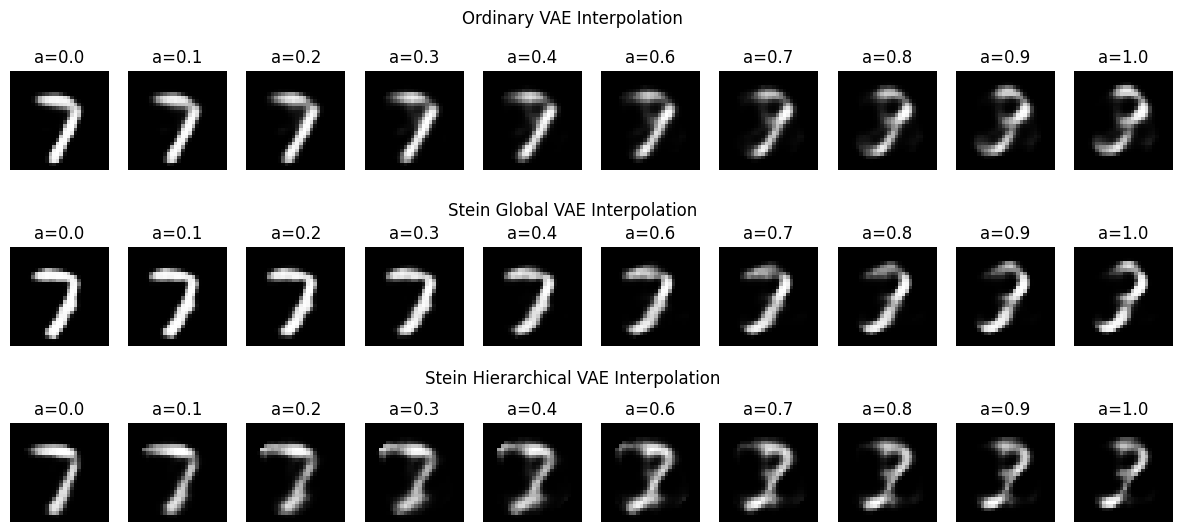

In [ ]:
img1 = X_test[3] 
img2 = X_test[10] 
plot_linear_interpolation_hierarchical(img1, img2)


Example of Hierarchical model having more holes

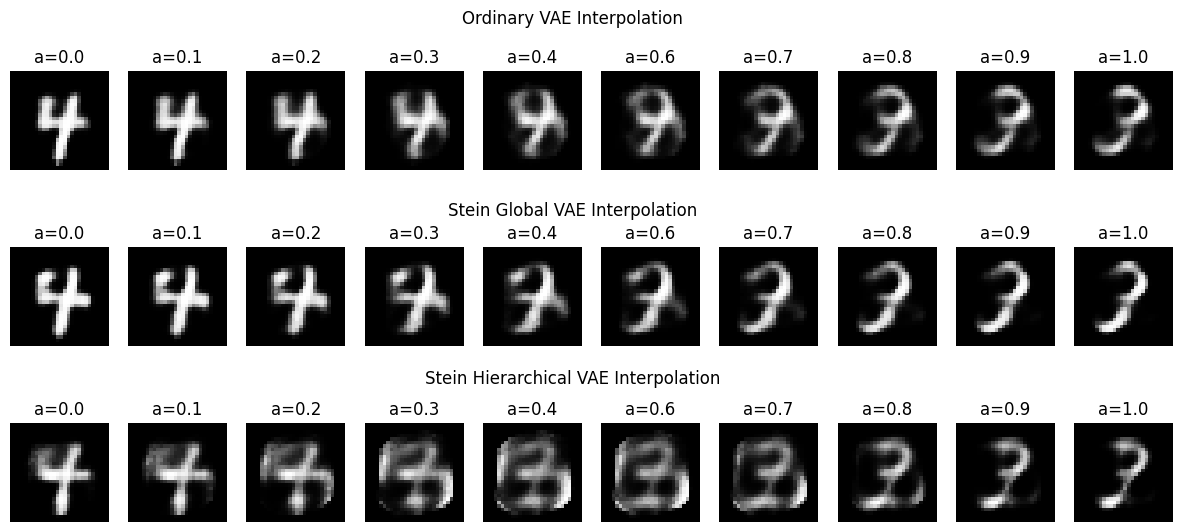

In [ ]:
img1 = X_test[1] 
img2 = X_test[10] 
plot_linear_interpolation_hierarchical(img1, img2)


## Convergence of Stein Norms

In [41]:
total = stein_global_vae_norms.shape[0]


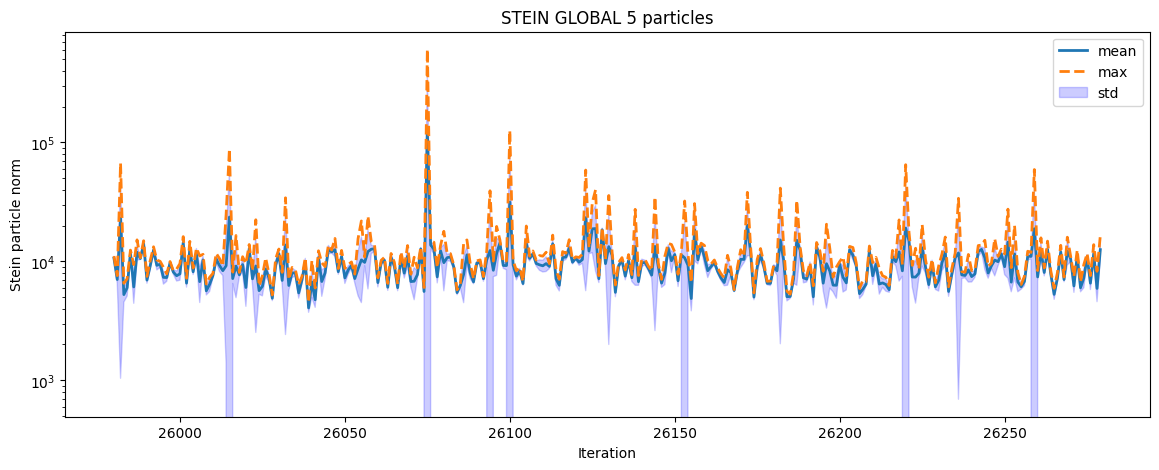

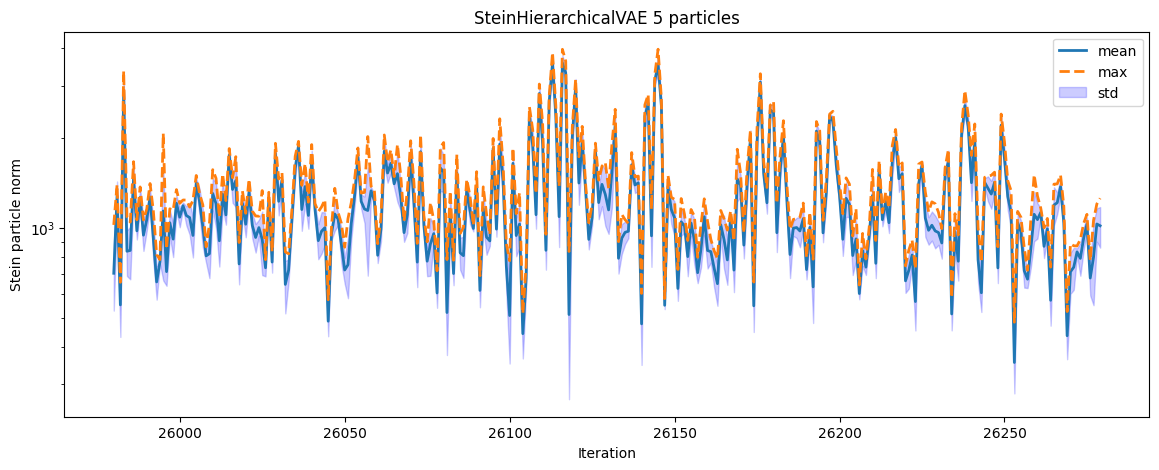

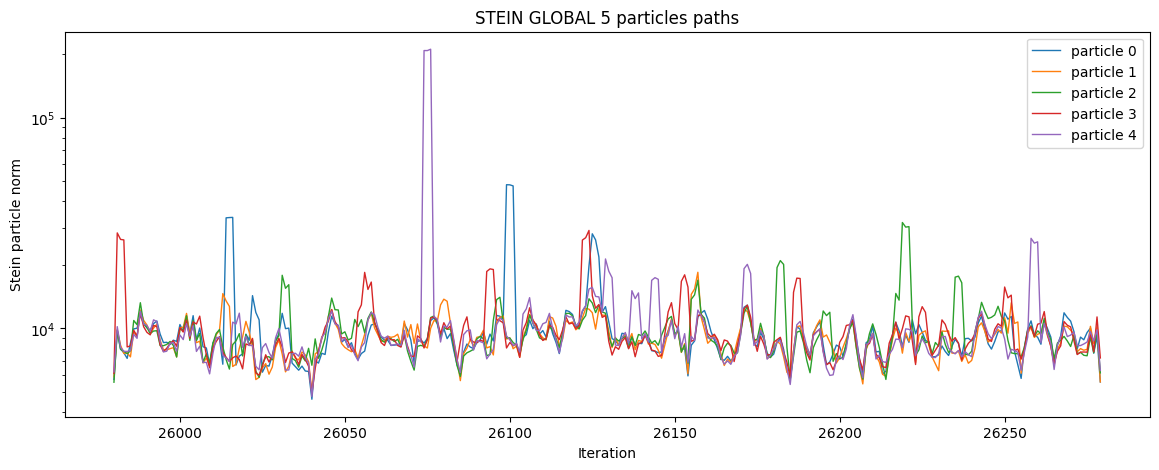

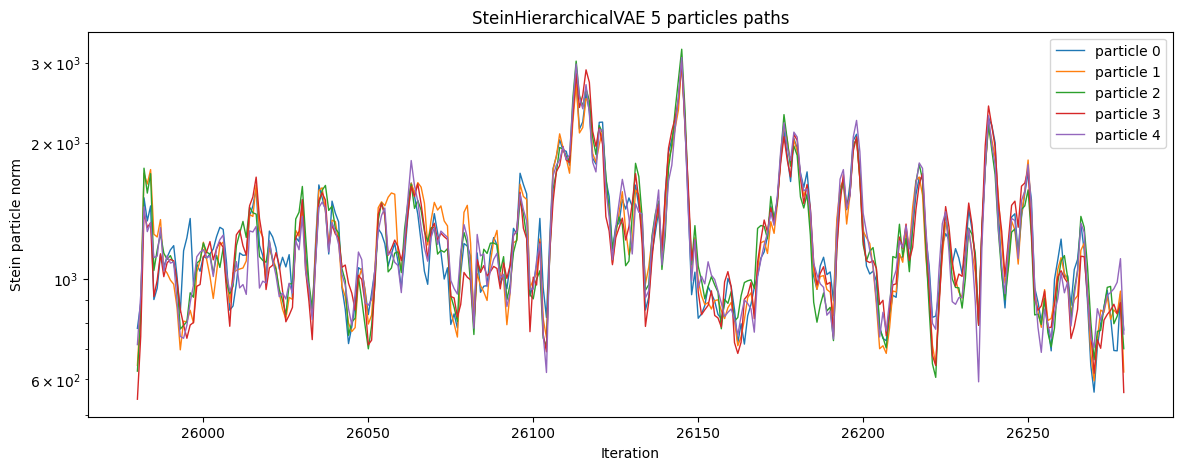

In [42]:
stein_global_stats = plot_stein_norms(stein_global_vae_norms, f"STEIN GLOBAL {num_stein_particles} particles", slice(total-300, total))
stein_hierarchical_stats = plot_stein_norms(stein_hierarchical_vae_norms, f"SteinHierarchicalVAE {num_stein_particles} particles", slice(total-300, total))
stein_global_paths = plot_individual_norm_paths(stein_global_vae_norms, f"STEIN GLOBAL {num_stein_particles} particles paths", slice(total-300, total))
stein_hierarchical_paths = plot_individual_norm_paths(stein_hierarchical_vae_norms, f"SteinHierarchicalVAE {num_stein_particles} particles paths", slice(total-300, total))

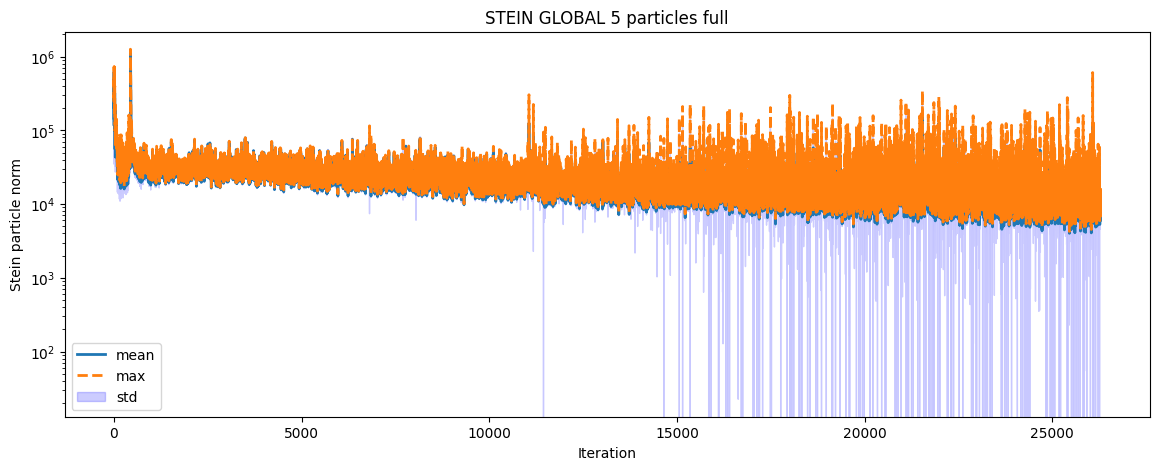

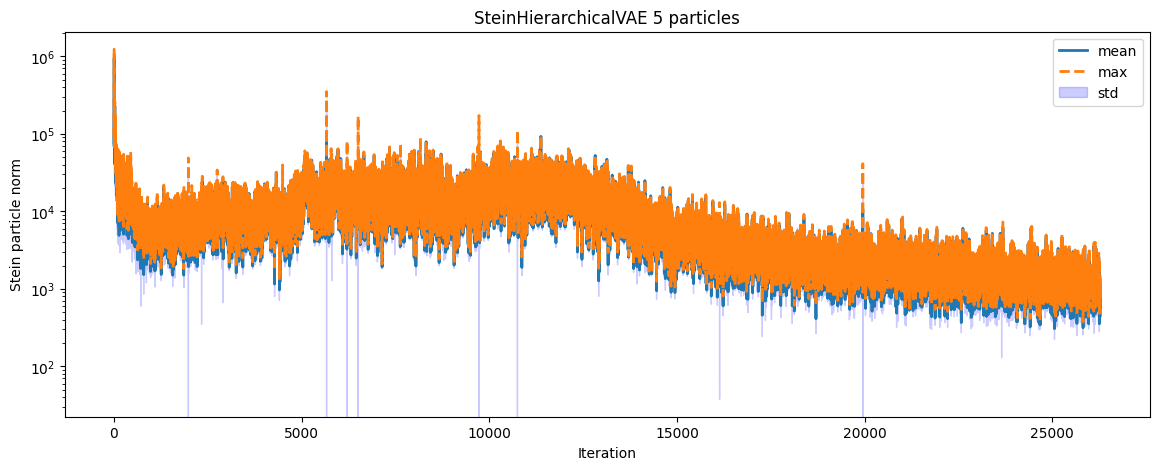

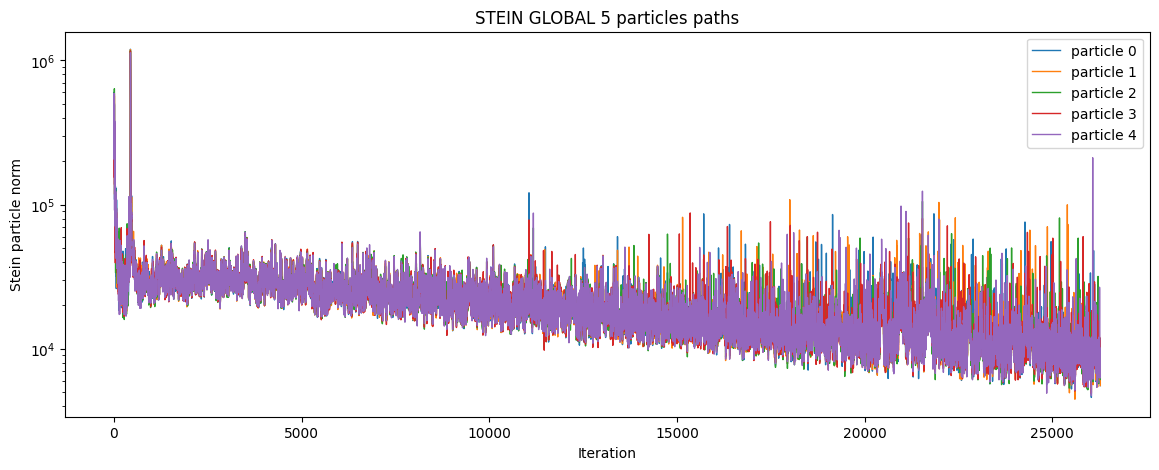

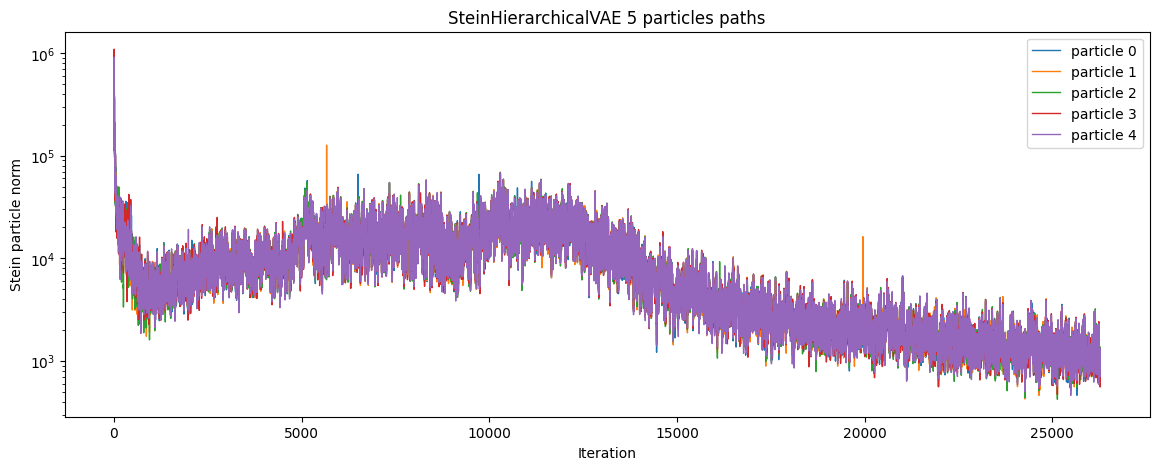

In [43]:
stein_global_stats = plot_stein_norms(stein_global_vae_norms, "STEIN GLOBAL 5 particles full", slice(0, 10000000))
stein_hierarchical_stats = plot_stein_norms(stein_hierarchical_vae_norms, "SteinHierarchicalVAE 5 particles", slice(0, 10000000))
stein_global_paths = plot_individual_norm_paths(stein_global_vae_norms, "STEIN GLOBAL 5 particles paths", slice(0, 10000000))
stein_hierarchical_paths = plot_individual_norm_paths(stein_hierarchical_vae_norms, "SteinHierarchicalVAE 5 particles paths", slice(0, 10000000))

These results indicate that the stein norms for m did not converge, which suggest undertraining, too high variance in the elbo, or too high variance between batches